# Run SCA and weighted PCA on center-out (red and yellow, long delay) reaching data. Plot projections in pca and sca dimensions
- first generate Balboa figures, then Alex.
- Use default orthogonality and sparsity penalties for SCA

## Import packages

In [1]:
import numpy as np
import numpy.random as npr
from scipy import io
import seaborn as sns
import time

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from sca.models import SCA, WeightedPCA
from sca.util import get_sample_weights,get_accuracy
from plotly.subplots import make_subplots

# add appropriate directories to search path
import sys
sys.path.append('../generate_paper_figures/utils')

from centerOutReaching_utils import calculateEpochOccupancy
from centerOutReaching_utils import calculateOccDispersion
from centerOutReaching_utils import calculateAI
from centerOutReaching_utils import calculateChanceAI
from parallelFunctions import bootstrapNeurons_SCA_PCA

import time


## Load Data

In [2]:
# which monkey are we working with?
monkName = 'Balboa'

In [3]:
# folder with rates
load_folder='../../datasets/'

# load data
data=io.loadmat(load_folder + monkName + '_outAndBack_redYellowConds_rawRates.mat')

# pull out the psths
# data is a C x N x T tensor 
data_array=data['data']

## Preprocess data


In [4]:
#Downsample data (using a factor of 10 here)
data_downsamp=data_array[:,:,np.arange(0,data_array.shape[2],10)]

# pull out some useful numbers
numConds,numN,trlDur = np.shape(data_downsamp)

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_concat=data_downsamp.swapaxes(0,1).reshape([data_downsamp.shape[1],data_downsamp.shape[0]*data_downsamp.shape[2]])

#fr range
fr_range=np.ptp(data_concat,axis=1)[:,None]

# make a time mask
timeMask = np.tile(np.arange(trlDur),(1,numConds)).T.flatten()

# define the times we want to use for sca/pca
# target on: 20
# move on:   77
# return:    200
trainTimes = np.arange(20,230)

# define a 'training mask' for convenience 
trainMask = np.in1d(timeMask,trainTimes)

#Subtract cross-condition mean
data_scm=data_downsamp-np.mean(data_downsamp,axis=0)[None,:,:]

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_scm_concat=data_scm.swapaxes(0,1).reshape([data_scm.shape[1],data_scm.shape[0]*data_scm.shape[2]])

#Soft normalize (divide each neuron by its fr range + 5)
data_scm_norm=data_scm_concat/(fr_range+5)

# mean-center the data
dMean = np.tile(np.mean(data_scm_norm,axis=1)[:,np.newaxis],(1,data_scm_norm.shape[1]))
data_mc = data_scm_norm - dMean

# rename the data for convenience
#Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
fit_data=np.copy(data_mc.T)

# how much to weight each timestep (used by)
sample_weights=get_sample_weights(fit_data)

# number of dimensions to find
R_est=8

# Whether or not to impose hard orthogonality constraint
hardOrthFlag = True



## Fit SCA

Using lam_sparse=  0.026212590511950663
Using device cpu
505.6156
3140.1055


100%|██████████| 3000/3000 [00:37<00:00, 79.05it/s]


43.69561004638672


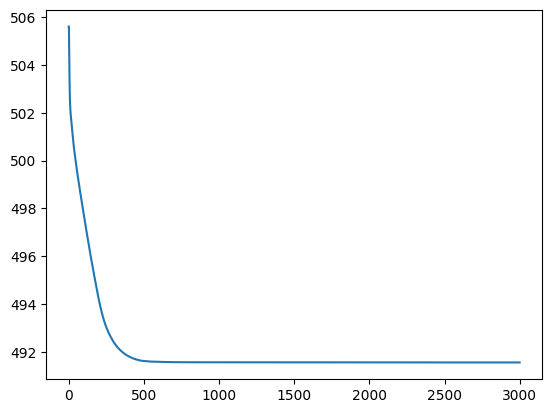

In [5]:
# fit model
start = time.time()
sca = SCA(n_components=R_est, orth=hardOrthFlag)
sca.fit(X=fit_data[trainMask,:], sample_weight=sample_weights[trainMask])

end = time.time()
print(end-start)

# grab weights
scaW = sca.params['U']

# project all of the data into the sca dimensions
sca_latent = sca.transform(fit_data)

# plot loss
losses = sca.losses
plt.plot(losses);



In [6]:
# display R2
print('SCA R2: ' + str(sca.r2_score))

SCA R2: 0.6259812608420148


In [7]:
# plot the dot product of the learned U weights (which are not constrained to be orthogonal)
U_dProd = scaW.T@scaW

# plot
fig = px.imshow(U_dProd)
fig.update_layout(height = 300, width = 300,title = 'dot product of U')

In [8]:
# plot the dot product of the learned V weights (which may or may not be constrained to be orthogonal, depending on the 'orthFlg') 
V_dProd = sca.params['V']@sca.params['V'].T

# plot
fig = px.imshow(abs(V_dProd),range_color = [0,0.5])
fig.update_layout(height = 300, width = 300,title = 'dot product of V')

### Fit PCA for comparison

In [9]:
wpca = WeightedPCA(n_components=R_est)
wpca.fit(fit_data[trainMask,:], sample_weight=sample_weights[trainMask])
pca_latent = wpca.transform(fit_data)


# get the factor weights
U_est = wpca.params['U']
V_est = wpca.params['V']

# calculate reconstruction R2
[pca_r2_score, pca_reconstruction_loss]=get_accuracy(wpca,fit_data[trainMask,:],sample_weights[trainMask])

# display results
print('PCA R2: ' + str(pca_r2_score))

PCA R2: 0.6302360309864747


### define some plotting colors
 - sca is purple -> light purple
 - I used https://davidjohnstone.net/lch-lab-colour-gradient-picker

In [10]:
# define sca colors
sca_cMap  = ['#5e0044', '#6f144e', '#812858', '#933c62', '#a5506d', '#b76477', '#c97881', '#db8c8c']

## Plot latents

### Plot when reordering by time of maximal influence

In [11]:
# calculate across-condition variance of each projection as a function of time

# reshape both latents to be size T x C x K 
rs_sca_latent = np.reshape(sca_latent,(-1,8,R_est),order = 'F')

# calculate across condition variance
sca_var = np.var(rs_sca_latent,axis = 1)

# find peak occupancy of each dimension
pkIdx = np.argmax(sca_var,axis = 0)

# define plotting order
sca_order = np.argsort(pkIdx)

# resort sca_latents by time of maximum occupancy
rs_sca_latent = rs_sca_latent[:,:,sca_order]

# do the same for the pca projections
rs_pca_latent = np.reshape(pca_latent,(-1,8,R_est),order = 'F')

pca_var = np.var(rs_pca_latent,axis = 1)
pkIdx = np.argmax(pca_var,axis = 0)
pca_order = np.argsort(pkIdx)
rs_pca_latent = rs_pca_latent[:,:,pca_order]

# define some useful time points
tgt_idx=20
move_idx=77
ret_idx=200


In [12]:
# # alternatively, order latents by the time that occupancy crosses some threshold
#
# # reshape both latents to be size T x C x K
# rs_sca_latent = np.reshape(sca_latent,(-1,8,R_est),order = 'F')
#
# # calculate across condition variance
# sca_var = np.var(rs_sca_latent,axis = 1)
#
# # for each occupancy trace, calculate when it crosses some (low) threshold
# threshTime_sca = np.zeros(R_est)
# threshold = 0.01
# for ii in range(R_est):
#     threshTime_sca[ii] = int(np.argwhere(sca_var[:,ii] > threshold)[0])
#
# # sort this list
# sca_order = np.argsort(threshTime_sca)
#
# # re-arrange latents
# rs_sca_latent = rs_sca_latent[:,:,sca_order]
#
# # now do the same for pca
# rs_pca_latent = np.reshape(pca_latent,(-1,8,R_est),order = 'F')
#
# pca_var = np.var(rs_pca_latent,axis = 1)
#
# threshTime_pca = np.zeros(R_est)
# threshold = 0.01
# for ii in range(R_est):
#     threshTime_pca[ii] = int(np.argwhere(pca_var[:,ii] > threshold)[0])
#
# # sort this list
# pca_order = np.argsort(threshTime_pca)
# rs_pca_latent = rs_pca_latent[:,:,pca_order]

In [13]:
# Define the directory for our new figures
figDir = '..'

#### SCA

In [14]:


# range for y axis
yRange = [-1.8,1.8]

fig = make_subplots(rows=R_est,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(R_est):

    for jj in range(numConds):
        latTrace = go.Scatter(y = rs_sca_latent[:,jj,ii], line = go.scatter.Line(color = sca_cMap[jj],width = 2.5),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)
        if ii == (R_est-1):
            fig.add_vline(x = tgt_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = ret_idx,row = ii+1,col = 1, line_color = 'black')

            #
    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


fig.update_layout(height = 2000,width =600,title = 'SCA ' + monkName,title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = R_est,col = 1)


# save
#fig.write_image(figDir + monkName + 'SCA_' + str(R_est) + 'dims.pdf')
#fig.show()


### Calculate the fractional occupancy for each epoch for each dimension
    - for reference:
    tgt_idx=20
    move_idx=77
    ret_idx=200

In [15]:
# define a vector of times, where 0 is the start of the trial (not target onset)
time = list(range(rs_sca_latent.shape[0]))

# define a prep. time
# outward reach
prepTime = list(range(tgt_idx,move_idx))
# return reach
prepTime.extend(list(range(ret_idx - 30, ret_idx)))

# execution time
# outward reach
moveTime = list(range(move_idx,move_idx + 30))
# return reach
moveTime.extend(list(range(ret_idx, ret_idx + 30 )))

# posture time
postTime = list(range(move_idx + 30,ret_idx - 30))

# plot all of our chosen times to make sure they make sense
fig = go.Figure(go.Scatter(y = np.isin(time,prepTime), name = 'prep'))
fig.add_trace(go.Scatter(y = np.isin(time,moveTime), name = 'move'))
fig.add_trace(go.Scatter(y = np.isin(time,postTime),name = 'post'))

fig.add_vline(x = tgt_idx, line_color = 'white',annotation_text = 'target on',annotation_position = 'top')
fig.add_vline(x = move_idx, line_color = 'white',annotation_text = 'move out',annotation_position = 'top')
fig.add_vline(x = ret_idx, line_color = 'white',annotation_text = 'return move',annotation_position = 'top')

fig.update_layout(height = 400,width = 700)

In [16]:
# calculate fractional occupancy
fractOcc_sca = calculateEpochOccupancy(rs_sca_latent,prepTimes = prepTime, moveTimes = moveTime, postTimes = postTime, projTimes = time)
fractOcc_pca = calculateEpochOccupancy(rs_pca_latent,prepTimes = prepTime, moveTimes = moveTime, postTimes = postTime, projTimes = time)

In [17]:
# calculate dispersion for each dimension (sum of absolute difference between each fractional occupancy)
disp_sca = calculateOccDispersion(fractOcc_sca)
disp_pca = calculateOccDispersion(fractOcc_pca)

In [18]:
# plot results
zMin = 0
zMax = 0.7

# initialize a figure
fig = make_subplots(rows=1,cols = 2,shared_xaxes = False,shared_yaxes = False,horizontal_spacing = 0.1, subplot_titles = ['SCA','PCA'])

# sca first
htPlt = go.Heatmap(go.Heatmap(z = fractOcc_sca,zmin = zMin, zmax = zMax, colorscale = 'Brwnyl'))
fig.add_trace(htPlt, row=1, col=1)

# pca
htPlt = go.Heatmap(go.Heatmap(z = fractOcc_pca,zmin = zMin, zmax = zMax, colorscale = 'Brwnyl'))
fig.add_trace(htPlt, row=1, col=2)

fig.update_yaxes(autorange = 'reversed',title = 'dimension')
fig.update_xaxes(title = 'epoch',tickmode = 'array',
                 tickvals = [0,1,2],
                 ticktext = ['prep.','exec.','post.'])

fig.update_layout(width = 800,height = 500,title = 'Epoch Sparsity ' + monkName)

# save figure
#fig.write_image(figDir + monkName + '_SCAPCA_' + str(R_est) + 'dims_epochSparsityMap.pdf')
#fig.show()

In [19]:
# display the max value of each row
print(np.max(fractOcc_sca,axis = 1))

[0.93692321 0.89013547 0.85231251 0.61229873 0.66996652 0.7016477
 0.85686213 0.91128778]


### generate PCA and SCA latents from bootstrapped neuron populations
    - using the same population for each

In [20]:
# make copies to use as arguments for function we're going to parallelize
# copy R_est, fit_data, and trainMask

# number of bootstraps
numBoots = 500

inputList = []
for ii in range(numBoots):
    inputList.append([R_est,fit_data,trainMask])


In [21]:
# run bootstrapping function
from multiprocessing.pool import Pool

# set up parallel pool to use all available workers
pool = Pool()

# bootstrap
output = pool.starmap(bootstrapNeurons_SCA_PCA,inputList)

Using lam_sparse=  0.02054536103170357
Using lam_orthog=  122.64996279768503
Using device cpu
Using lam_sparse=  0.02410810624464
Using lam_orthog=  134.78220118150008
Using device cpu
413.97214
3343.0405
436.75906
3130.8154
Using lam_sparse=  0.021677525373737617
Using lam_orthog=  127.59023313073693
Using device cpu
Using lam_sparse=  0.023076861848251664
414.80612
3296.065
Using lam_orthog=  132.69114754796146
Using device cpu
439.75168
3219.9805
Using lam_sparse=  0.02146504366184082
Using lam_orthog=  127.71447908465973
Using device cpu
Using lam_sparse=  0.023758731516551067
Using lam_sparse=  0.020512792992043945
Using lam_orthog=  134.97914991647568
Using device cpu
Using lam_orthog=  116.79536974264177
Using device cpu
425.29294
3331.934
482.25317
3181.4966
399.29913
3188.518
Using lam_sparse=  0.022409654499231796
Using lam_orthog=  127.4057573272556
Using device cpu


  0%|          | 2/3000 [00:00<02:31, 19.77it/s]

440.58795
3183.7717


100%|██████████| 3000/3000 [00:29<00:00, 101.38it/s]


Using lam_sparse=  0.024591967143976937
Using lam_orthog=  142.32351667095935
Using device cpu
484.343
3240.9434
Using lam_sparse=  0.02433100908293688
Using lam_orthog=  137.6710754481347
Using device cpu
493.31833
3168.6233
Using lam_sparse=  0.025387241249545493
Using lam_sparse=  0.02580201311448062
Using lam_sparse=  0.02386845687540582


...

 10%|█         | 304/3000 [00:01<00:14, 192.29it/s]]

Using lam_sparse=  0.02136910048652133
Using lam_orthog=  124.38924954356204
Using device cpu
434.00784
3259.7527
Using lam_sparse=  0.023916095321555666
Using lam_orthog=  139.4832127291312
Using device cpu
470.1001
3266.0264


 18%|█▊        | 540/3000 [00:02<00:12, 190.61it/s]]

Using lam_sparse=  0.020300914829643135
Using lam_orthog=  129.2617171624753
Using device cpu
425.4835
3565.6797


100%|██████████| 3000/3000 [00:13<00:00, 221.00it/s]


In [22]:
# close the pool
pool.close()

In [27]:
# parse outputs and save
numReps = len(output)
sca_latents_all = np.zeros((fit_data.shape[0],R_est,numReps))
pca_latents_all = np.zeros((fit_data.shape[0],R_est,numReps))


for ii in range(numReps):
    sca_latents_all[:,:,ii] = output[ii][0]
    pca_latents_all[:,:,ii] = output[ii][1]


# save intermediate results (the bootstrapped latents) so we don't have to re-run the bootstrapping function if we want to make changes to the plotting code
saveDir = '../../datasets/'
np.save(saveDir + monkName + '_sca_pca_bootstrappedLatents_' + str(R_est) + 'Dims.npy', {'sca_latents': sca_latents_all,'pca_latents':pca_latents_all})

In [ ]:
# load the latents if we need to
saveDir = '../../datasets/'
data = np.load(saveDir + monkName + '_sca_pca_bootstrappedLatents_8Dims.npy',allow_pickle=True)
data = data.item()
sca_latents = data['sca_latents']
pca_latents = data['pca_latents']


In [29]:
# for each set of sca (and pca) latents, calculate epoch sparsity matrix, then median sparsity value (need to come up with a better name) across dimensions

# initialize two vectors to hold results
numBoots = sca_latents.shape[2]
sparseIdx_sca = np.zeros(numBoots)
sparseIdx_pca = np.zeros(numBoots)

# cycle through bootstraps
for ii in range(numBoots):

    # reshape pca and sca projections to be T x C x K
    sca_rs = sca_latents[:,:,ii].reshape(-1,8,R_est,order = 'F')
    pca_rs = pca_latents[:,:,ii].reshape(-1,8,R_est,order = 'F')


    # calculate fractional occupancy
    fractOcc_sca = calculateEpochOccupancy(sca_rs,prepTimes = prepTime, moveTimes = moveTime, postTimes = postTime, projTimes = time)
    fractOcc_pca = calculateEpochOccupancy(pca_rs,prepTimes = prepTime, moveTimes = moveTime, postTimes = postTime, projTimes = time)

    # calculate dispersion for each dimension (sum of absolute difference between each fractional occupancy row)
    disp_sca = calculateOccDispersion(fractOcc_sca)
    disp_pca = calculateOccDispersion(fractOcc_pca)

    # save mean across dimensions
    sparseIdx_sca[ii] = np.copy(np.mean(disp_sca))
    sparseIdx_pca[ii] = np.copy(np.mean(disp_pca))




In [30]:
# define sca and pca colors
eBarColors = ['#5e0044','#a79ba4']

# combine data into lists to make life easy
sparseIdx = [np.copy(sparseIdx_sca), np.copy(sparseIdx_pca)]

# define some plotting parameters
eBarThickness = 5
eBarWidth = 10
markerSize = 15
markerLineWidth = 2

# sca
fig = go.Figure(data = go.Scatter(
    x = [0],y = [np.mean(sparseIdx[0])],
    error_y = dict(
        type = 'data',
        array = [np.std(sparseIdx[0])],visible = True,thickness = eBarThickness,width = eBarWidth),
    marker = dict(
        color = eBarColors[0],
        size = markerSize,
        line = dict(
            color = 'black',
            width = markerLineWidth
        )
    ),showlegend = False
    )
)

# pca
pcaTrace = go.Scatter(
    x = [1],y = [np.mean(sparseIdx[1])],
    error_y = dict(
        type = 'data',
        array = [np.std(sparseIdx[1])],visible = True,thickness = eBarThickness,width = eBarWidth),
    marker = dict(
        color = eBarColors[1],
        size = markerSize,
        line = dict(
            color = 'black',
            width = markerLineWidth
        )
    ),showlegend = False
)
fig.add_trace(pcaTrace)

# clean up figure
fig.update_layout(height =500,width =350,title = 'SCA vs. PCA epoch sparsity ' + monkName,title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False)
fig.update_yaxes(color = 'black',ticks = 'outside',visible = True,showline = True,linewidth = 1.5,tickwidth = 1.5)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,1],ticktext = ['SCA','PCA'],visible = True,tickwidth = 1.5)

# save figure
# fig.write_image(figDir + monkName + '_SCA_vs_PCA_' + str(R_est) + 'dims_bootstrap_epochSparsitySummary.pdf')
# fig.show()

In [31]:
# calculate pVal for sparseIdx_sca < sparseIdx_pca
scaBigger = [1 if x < y else 0 for x,y in zip(sparseIdx[0],sparseIdx[1])]
pVal = sum(scaBigger) / len(scaBigger)
print('bootstrap pVal: ' + str(pVal) + ' (' + str(numBoots) +' bootstraps)')

bootstrap pVal: 0.0 (500 bootstraps)


### Calculate the (pairwise) alignment indices between prep_out, move_out, posture, prep_return, and move_return
    for reference:
    tgt_idx=20
    move_idx=77
    ret_idx=200

In [ ]:
# # define the time periods for each epoch

# # prep
# prepOut = list(np.arange(tgt_idx,move_idx - 10))
# prepRtn = list(np.arange(ret_idx - 30,ret_idx - 10))


# # move
# moveOut = list(np.arange(move_idx,move_idx + 20))
# moveRtn = list(np.arange(ret_idx,ret_idx + 20))

# # posture
# post = list(np.arange(move_idx + 30,ret_idx - 50))

# # place everything in a list
# epochTimes = [prepOut, moveOut, post, prepRtn, moveRtn]
# numEpochs = len(epochTimes)

# # number of dimensions to use for alignemnt index calculation
# numDims = 10

# # make a 'numEpochs' x 'numEpochs' matrix to hold results
# allAI = np.zeros((numEpochs,numEpochs))

# # cycle through all epochs
# for ii in range(numEpochs):
#     for jj in range(numEpochs):

#         # grab data from epoch ii
#         X1 = fit_data[np.isin(timeMask,epochTimes[ii]),:]

#         # data from epoch jj
#         X2 = fit_data[np.isin(timeMask,epochTimes[jj]),:]

#         # calculate alignment index
#         allAI[ii,jj] = calculateAI(X1,X2,numDims)

# # calculate change AI
# chanceAI = calculateChanceAI(fit_data,numDims)

../generate_paper_figures/utils/centerOutReaching_utils.py:139: RuntimeWarning:

invalid value encountered in sqrt



LinAlgError: SVD did not converge

In [ ]:
# # calulate median chance AI
# medChanceAI = np.median(chanceAI)
# print('chance AI: ' + str(medChanceAI))

# # plot results
# fig = go.Figure(go.Heatmap(z = allAI,zmin = 0, zmax = 1,colorscale = 'Electric'))

# # add labels
# fig.update_layout(yaxis = dict(
#     tickmode = 'array',
#     tickvals = [0,1,2,3,4],
#     ticktext = ['prep out','move out','posture','prep rtn','move rtn']),
#                 xaxis = dict(
#     tickmode = 'array',
#     tickvals = [0,1,2,3,4],
#     ticktext = ['prep out','move out','posture','prep rtn','move rtn'],
#     tickcolor = 'black'),
#                 width = 500,height = 500,title = monkName + ' alignment indices')


# fig.show()

# # save figure (as html).
# # fig.write_html(figDir + monkName + '_' + str(R_est) + 'dims_aligmentIndex.html')


NameError: name 'chanceAI' is not defined

In [ ]:
# # initialize a figure

# fig = make_subplots(rows=1,cols = numDimCount,shared_xaxes = True,shared_yaxes = True,horizontal_spacing = 0.01, subplot_titles = [str(x) + ' dims' for x in numDimsInRun] )

# # cycle through runs with different number of dimensions
# for dd in range(numDimCount):

#     # reshape
#     tempDisp = disp_all_rs[:,dd]
#     tempDisp = tempDisp.reshape(numSparse,numOrthog,order = 'F')

#     # plot
#     tempImage = go.Heatmap(z = tempDisp, zmin = 0,zmax = 2,x = orthogLambdas,y = sparsityLambdas,colorscale = 'Magma')
#     fig.add_trace(tempImage, row = 1, col=dd+1)



# # fix some odd bug with the y axis tick labels
# fig.update_layout(yaxis = dict(
#     tickmode = 'array',
#     tickvals = [1e-4, 1e-2, 1, 100]))

# fig.update_xaxes(type = 'log')
# fig.update_yaxes(type = 'log')
# fig.update_layout(height = 600,width = 1000,xaxis_title = 'orthog lambda',yaxis_title = 'sparse lambdas',coloraxis_colorbar = dict(title = 'mean dispersion'),title = 'Epoch Dispersion')

# # fig.write_image(figDir + monkName + 'orth_sparse_lambdaSweeps_epochDispersion.pdf')
# # fig.show()

NameError: name 'numDimCount' is not defined

### Cycle through number of dimensions and calculate R2 of reconstructed neurons

In [37]:
# number of dimensions to test
numDims = np.arange(5,55,5)

# initialize vectors to hold results
R2_sca = np.zeros(numDims.shape[0]) + np.nan
R2_pca = np.zeros(numDims.shape[0]) + np.nan

# cycle through number of dimensions
for ii,jj in enumerate(numDims):

    # fit SCA
    sca = SCA(n_components=jj, orth=hardOrthFlag)
    sca.fit(X=fit_data[trainMask,:], sample_weight=sample_weights[trainMask])
    
    # calculate reconstruction R2
    X = fit_data[trainMask,:]
    X_hat = sca.reconstruct(X)
    X_hat = X_hat.reshape(-1,1,order = 'F')
    X = X.reshape(-1,1,order = 'F')

    SS_tot = np.sum( (X - np.mean(X))**2)
    SS_res = np.sum( (X - X_hat)**2)

    R2_sca[ii] = 1 - (SS_res/SS_tot)

    # fit PCA
    wpca = WeightedPCA(n_components=jj)
    wpca.fit(fit_data[trainMask,:], sample_weight=sample_weights[trainMask])

    # calculate reconstruction R2
    X = fit_data[trainMask,:]
    X_hat = wpca.reconstruct(X)
    X_hat = X_hat.reshape(-1,1,order = 'F')
    X = X.reshape(-1,1,order = 'F')

    SS_tot = np.sum( (X - np.mean(X))**2)
    SS_res = np.sum( (X - X_hat)**2)

    R2_pca[ii] = 1 - (SS_res/SS_tot)



Using lam_sparse=  0.045934921688775596
Using device cpu
642.68085
2343.234


100%|██████████| 3000/3000 [00:29<00:00, 100.90it/s]


Using lam_sparse=  0.019847355829001143
Using device cpu
444.0778
3567.3525


100%|██████████| 3000/3000 [00:27<00:00, 107.61it/s]


Using lam_sparse=  0.011447073497529768
Using device cpu
331.71606
4527.4507


...

100%|██████████| 3000/3000 [00:35<00:00, 84.15it/s] 


Using lam_sparse=  0.0017752342346330867
Using device cpu
88.99205
7784.487


100%|██████████| 3000/3000 [00:36<00:00, 82.51it/s]


Using lam_sparse=  0.001379231630211133
Using device cpu
72.32785
8139.0117


100%|██████████| 3000/3000 [00:32<00:00, 91.41it/s] 


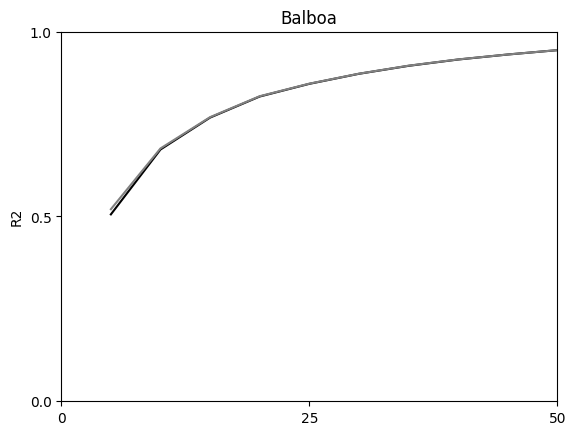

In [38]:
# plot results

# change color of axis labels so we can see them in the pdf
plt.rcParams['text.color'] = 'k'
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'
plt.rcParams['axes.labelcolor'] = 'k'

# plot sca results
plt.plot(numDims, R2_sca,'k',label='sca')

# and pca results
plt.plot(numDims,R2_pca,color=[0.5,0.5,0.5],label='pca')

# clean up
plt.xlim((0, 50));plt.ylim((0,1));
plt.xticks(np.array([0,25,50]));
plt.yticks(np.array([0,0.5, 1]));
plt.title(monkName);
plt.ylabel('R2');


# # # save directory
# figDir = '/Users/andrew/Documents/Projects/Churchland/Sparsity/figures/centerOutReaching/'

# # save
# plt.savefig(figDir + monkName + '_scaVsPCA_reconError.pdf',dpi = 'figure')

In [39]:
# Hold out both neurons and conditions (inset figure)


def get_sses_pred(y_test,y_test_pred):
    sse=np.sum((y_test_pred-y_test)**2,axis=0)
    return sse

def get_sses_mean(y_test):
    y_mean=np.mean(y_test,axis=0)
    sse_mean=np.sum((y_test-y_mean)**2,axis=0)
    return sse_mean
def r2_norm(y,y_pred):
    return 1-np.sum((y-y_pred)**2)/np.sum((y-np.mean(y))**2)

Y2=np.copy(fit_data) #copy neural data
num_nrns=Y2.shape[1]

ks= np.append(list(range(1, 10, 1)),list((range(10, 51, 5)))) #R_est to loop across
print(ks)

num_cv_neurons = 10 #(1/num_cv_neurons)% neurons are held out each time; 4->25%, 10->10%
num_cv_conds = 8 #8/num_cv_conds are held out each time; 2->4 conds, 4->2 conds, 8->1 cond

#initialize arrays to hold r2
holdOut_rest_pca_r2=np.zeros((len(ks),num_nrns))
holdOut_rest_sca_r2=np.zeros((len(ks),num_nrns))
holdOut_rest_pca_mr2 = np.zeros((len(ks),1))
holdOut_rest_sca_mr2 = np.zeros((len(ks),1))

[ 1  2  3  4  5  6  7  8  9 10 15 20 25 30 35 40 45 50]


In [40]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
# to save predictions across condition splitting
Y_pca_pred_rest = np.zeros((len(ks),numConds*trlDur, numN)) 
Y_sca_pred_rest = np.zeros((len(ks),numConds*trlDur, numN))
## Loop R_est
for k,r_est in enumerate(ks):
    ## Loop neuron splitting
    kf2 = KFold(n_splits=num_cv_neurons,shuffle=True)   
    for train_index, test_index in kf2.split(np.arange(num_nrns)):

        train_nrns=np.arange(num_nrns)[train_index]
        test_nrns=np.arange(num_nrns)[test_index]
        
        s_weight=get_sample_weights(Y2)
        Y2_train = Y2[trainMask,:]
        
        #Fit PCA to all time on subset of neurons
        wpca = WeightedPCA(n_components=r_est)
        wpca.fit(Y2_train[:,train_nrns], sample_weight=s_weight[trainMask])
        pca_lat = wpca.transform(Y2[:,train_nrns])
        #Fit SCA
        sca = SCA(n_components=r_est, orth=False)
        sca.fit(X=Y2_train[:,train_nrns], sample_weight=s_weight[trainMask])
        sca_lat = sca.transform(Y2[:,train_nrns])

        ## Loop condition splitting
        kf3 = KFold(n_splits=num_cv_conds,shuffle=True)       
        for train_idx, test_idx in kf3.split(np.arange(numConds)):
            #get time ranges of train and test conditions
            ranges = []
            for i, train_cond in enumerate(train_idx):
                ranges.append(list(range(train_cond*trlDur, (train_cond+1)*trlDur)))
            train_time = sum(ranges, [])
            test_time = np.setdiff1d(range(0, numConds*trlDur), train_time)
            
            Y2_test_nrns = Y2[:,test_nrns]
            y_test_train_time = Y2_test_nrns[train_time,:]
            y_test_test_time = Y2_test_nrns[test_time,:]
            
            #PCA
            latent_train_time = pca_lat[train_time, :]
            latent_test_time = pca_lat[test_time, :]
           
            #Fit link function to training neurons during test time
            lr=LinearRegression()
            lr.fit(latent_train_time,y_test_train_time)

            #Get predictions of testing neurons during test time
            pca_pred=lr.predict(latent_test_time)
                            
            #SCA
            latent_train_time = sca_lat[train_time, :]
            latent_test_time = sca_lat[test_time, :]
            
            #Fit link function to training neurons during test time
            lr=LinearRegression()
            lr.fit(latent_train_time,y_test_train_time)

            #Get predictions of testing neurons during test time
            sca_pred=lr.predict(latent_test_time)
            
            #Save predictions to match neuron and time sequences in original data
            for j, test_nrn in enumerate(test_nrns):
                for c, test_cond in enumerate(test_idx):
                    Y_pca_pred_rest[k,test_cond*trlDur:(test_cond+1)*trlDur,test_nrn] = pca_pred[c*trlDur:(c+1)*trlDur,j]
                    Y_sca_pred_rest[k,test_cond*trlDur:(test_cond+1)*trlDur,test_nrn] = sca_pred[c*trlDur:(c+1)*trlDur,j]
        
        #Calculate R2 for each neuron 
        for nrn in range(num_nrns):            
            holdOut_rest_pca_r2[k,nrn] = r2_norm(Y2[:,nrn],Y_pca_pred_rest[k,:,nrn])
            holdOut_rest_sca_r2[k,nrn] = r2_norm(Y2[:,nrn],Y_sca_pred_rest[k,:,nrn])
    
    # Calculate multivariate R2 for concatenated predictions
    sses =get_sses_pred(Y2,Y_pca_pred_rest[k,:,:])
    sses_mean=get_sses_mean(Y2)
    holdOut_rest_pca_mr2[k] =1-np.sum(sses)/np.sum(sses_mean)     
    sses =get_sses_pred(Y2,Y_sca_pred_rest[k,:,:])
    holdOut_rest_sca_mr2[k] =1-np.sum(sses)/np.sum(sses_mean)    

Using lam_sparse=  0.25283972498135876
Using lam_orthog=  0
Using device cpu
907.7844
622.6656


100%|██████████| 3000/3000 [00:06<00:00, 445.94it/s]


Using lam_sparse=  0.2407454157669813
Using lam_orthog=  0
Using device cpu
935.34863
676.172


100%|██████████| 3000/3000 [00:06<00:00, 445.43it/s]


Using lam_sparse=  0.26949178880327057
Using lam_orthog=  0
Using device cpu
956.51776
612.48206


...

100%|██████████| 3000/3000 [00:11<00:00, 260.42it/s]


Using lam_sparse=  0.0011229158062270087
Using lam_orthog=  0.35526615908470516
Using device cpu
56.13883
7751.267


100%|██████████| 3000/3000 [00:12<00:00, 244.52it/s]


Using lam_sparse=  0.001217748535940842
Using lam_orthog=  0.38869741130816965
Using device cpu
60.591007
7820.24


100%|██████████| 3000/3000 [00:11<00:00, 262.55it/s]


In [41]:
# save intermediate results
saveDir = '../../datasets/'
np.save(saveDir + monkName + '_sca_pca_holdOut2_bootstrap.npy',
        {'pca_r2': holdOut_rest_pca_r2, 'sca_r2': holdOut_rest_sca_r2
           , 'pca_pred':Y_pca_pred_rest, 'sca_pred':Y_sca_pred_rest
           , 'pca_mr2': holdOut_rest_pca_mr2, 'sca_mr2': holdOut_rest_sca_mr2})
data = np.load(saveDir + monkName + '_sca_pca_holdOut2_bootstrap.npy',allow_pickle=True)
data = data.item()
Y_pca_pred_rest = data['pca_pred']
Y_sca_pred_rest = data['sca_pred']
holdOut_rest_pca_mr2 = data['pca_mr2']
holdOut_rest_sca_mr2 = data['sca_mr2']

In [42]:
#bootstrap to get error bars
bs_rest_pca = np.zeros((len(ks),100))
bs_rest_sca = np.zeros((len(ks),100))
for i in range(len(ks)):
    for b in range(100):
        nIdx = np.random.choice(num_nrns,num_nrns)      
        samp_truth = Y2[:,nIdx]
        sses_mean=get_sses_mean(samp_truth)
        
        pca_samp = Y_pca_pred_rest[i][:,nIdx]
        pca_sses =get_sses_pred(samp_truth,pca_samp)
        bs_rest_pca[i,b] =1-np.sum(pca_sses)/np.sum(sses_mean)     
        
        sca_samp = Y_sca_pred_rest[i][:,nIdx]
        sca_sses =get_sses_pred(samp_truth,sca_samp)
        bs_rest_sca[i,b] =1-np.sum(sca_sses)/np.sum(sses_mean)   

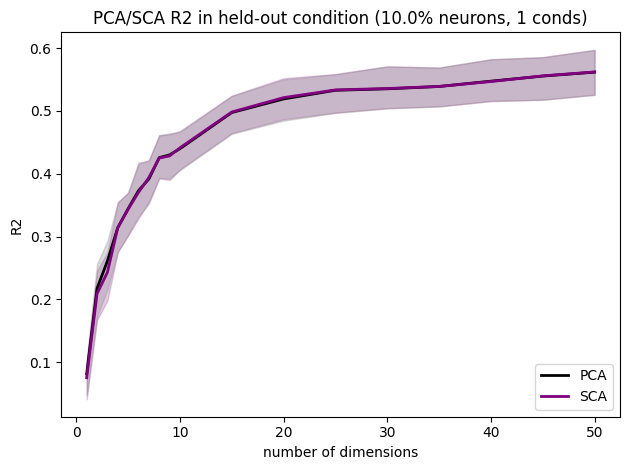

In [43]:
# change color of axis labels so we can see them in the pdf
plt.rcParams['text.color'] = 'k'
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'
plt.rcParams['axes.labelcolor'] = 'k'

#error bars
plt.fill_between(ks, np.mean(bs_rest_sca,axis=1) - np.std(bs_rest_sca,axis=1), np.mean(bs_rest_sca,axis=1) + np.std(bs_rest_sca,axis=1), color='purple', alpha=0.2)
plt.fill_between(ks, np.mean(bs_rest_pca,axis=1) - np.std(bs_rest_pca,axis=1), np.mean(bs_rest_pca,axis=1) + np.std(bs_rest_pca,axis=1), color='#888888', alpha=0.3)

# plot lines as multivariate R2 for concatenated predictions
plt.plot(ks, holdOut_rest_pca_mr2,color = 'k', label = "PCA",linewidth = 2, zorder = 3)
plt.plot(ks, holdOut_rest_sca_mr2,color = 'purple', label = "SCA",linewidth = 2, zorder = 3)

plt.legend(loc='lower right')
plt.xlabel('number of dimensions');
plt.ylabel('R2');
plt.title("PCA/SCA R2 in held-out condition ("+ str(1/num_cv_neurons*100) +"% neurons, " + str(int(numConds/num_cv_conds)) + " conds)")

# save
plt.tight_layout()
# plt.savefig(figDir + monkName + '_holdOut2_Rest.pdf', dpi = 'figure')